# What drives the price of a car?

![](images/kurt.jpeg)

**OVERVIEW**

In this application, you will explore a dataset from Kaggle. The original dataset contained information on 3 million used cars. The provided dataset contains information on 426K cars to ensure speed of processing.  Your goal is to understand what factors make a car more or less expensive.  As a result of your analysis, you should provide clear recommendations to your client -- a used car dealership -- as to what consumers value in a used car.

### CRISP-DM Framework

<center>
    <img src = images/crisp.png width = 50%/>
</center>


To frame the task, throughout our practical applications, we will refer back to a standard process in industry for data projects called CRISP-DM.  This process provides a framework for working through a data problem.  Your first step in this application will be to read through a brief overview of CRISP-DM [here](https://mo-pcco.s3.us-east-1.amazonaws.com/BH-PCMLAI/module_11/readings_starter.zip).  After reading the overview, answer the questions below.

### Business Understanding

From a business perspective, we are tasked with identifying key drivers for used car prices.  In the CRISP-DM overview, we are asked to convert this business framing to a data problem definition.  Using a few sentences, reframe the task as a data task with the appropriate technical vocabulary. 

In [1]:
#From a data perspective, this problem can be considered as a supervised machine learning/data analysis task focused on predicting used car prices. 

In [2]:
#The goal of this project is to analyze and understand the relationships between vehicle attributes like size, type, model, etc. in order to assess which variables most strongly influence vehicle valuation.

In [3]:
#Using statistical analysis, feature engineering, and predictive modeling techniques, the dataset will be cleaned, explored, and modeled to determine patterns in consumer preferences and market pricing behavior.

In [4]:
#The final result will be actionable insights that can help dealerships optimize inventory and pricing strategies, and target different customer demographics based on factors that contribute most strongly to vehicle value.

### Data Understanding

After considering the business understanding, we want to get familiar with our data.  Write down some steps that you would take to get to know the dataset and identify any quality issues within.  Take time to get to know the dataset and explore what information it contains and how this could be used to inform your business understanding.

In [5]:
#1. First inspect the structure of the data and check out the number of rows and columns, as well as summary statistics for numerical variables.

In [6]:
#2. Identify any issues with the data by checking for missing values, duplicate records, inconsistent formatting, etc. Visualizations such as histograms, boxplots, and correlation heatmaps could also help identify outliers, trends, and relationships between variables.

In [7]:
#3.Explore how different vehicle attributes relate to prices in order to determine which features may be the strongest predictors of vehicle value. This would help guide later stages of feature engineering and predictive modeling.

### Data Preparation

After our initial exploration and fine-tuning of the business understanding, it is time to construct our final dataset prior to modeling.  Here, we want to make sure to handle any integrity issues and cleaning, the engineering of new features, any transformations that we believe should happen (scaling, logarithms, normalization, etc.), and general preparation for modeling with `sklearn`. 

In [23]:
#import modules and packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


In [9]:
# Load dataset
df = pd.read_csv('data/vehicles.csv')

In [10]:
#view basic info about dataset
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 426880 entries, 0 to 426879
Data columns (total 18 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            426880 non-null  int64  
 1   region        426880 non-null  object 
 2   price         426880 non-null  int64  
 3   year          425675 non-null  float64
 4   manufacturer  409234 non-null  object 
 5   model         421603 non-null  object 
 6   condition     252776 non-null  object 
 7   cylinders     249202 non-null  object 
 8   fuel          423867 non-null  object 
 9   odometer      422480 non-null  float64
 10  title_status  418638 non-null  object 
 11  transmission  424324 non-null  object 
 12  VIN           265838 non-null  object 
 13  drive         296313 non-null  object 
 14  size          120519 non-null  object 
 15  type          334022 non-null  object 
 16  paint_color   296677 non-null  object 
 17  state         426880 non-null  object 
dtypes: f

In [11]:
#drop duplicate rows 
df = df.drop_duplicates()
#drop rows with missing price values
df = df.dropna(subset = ["price"])

#remove very low and high prices and odometer readings higher than 0
df = df[(df['price'] > 500) & (df['price'] < 100000)]
df = df[(df['odometer'] >= 0)]


### Modeling

With your (almost?) final dataset in hand, it is now time to build some models.  Here, you should build a number of different regression models with the price as the target.  In building your models, you should explore different parameters and be sure to cross-validate your findings.

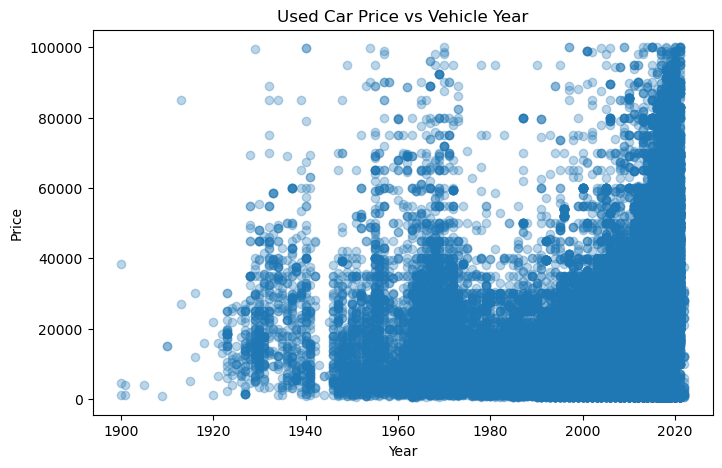

In [28]:
#Scatterplot for Car Price vs Vehicle Year
plt.figure(figsize=(8,5))

plt.scatter(df["year"], df["price"], alpha=0.3)

plt.xlabel("Year")
plt.ylabel("Price")
plt.title("Used Car Price vs Vehicle Year")

plt.show()

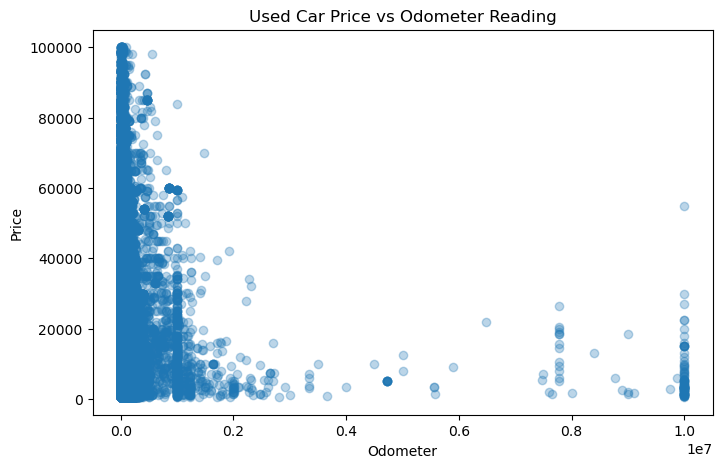

In [27]:
#Scatterplot for Car Price vs Odometer Reading
plt.figure(figsize=(8,5))

plt.scatter(df["odometer"], df["price"], alpha=0.3)

plt.xlabel("Odometer")
plt.ylabel("Price")
plt.title("Used Car Price vs Odometer Reading")

plt.show()

In [12]:
#Create a new feature for the age of the vehicle
curr_year = 2026
df['vehicle_age'] = curr_year - df['year']

In [13]:
#select features for comparison. We will look at odometer and the vehicle age that we just created since these are all numerical values
features = ['odometer', 'vehicle_age']
X = df[features]
y = df["price"]

#create Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [14]:
# Preprocessing pipeline for numerical data
numeric_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

In [15]:
#create machine learning models, start with linear regression
linear_model = Pipeline(steps=[
    ("preprocessor", numeric_pipeline),
    ("model", LinearRegression())
])

linear_model.fit(X_train, y_train)

y_pred = linear_model.predict(X_test)

print("Linear Regression")
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2:", r2_score(y_test, y_pred))

Linear Regression
MAE: 10161.221258767455
RMSE: 13193.255423095077
R2: 0.15356954476552598


In [16]:
#Ridge Regression and cross validation
ridge_model = Pipeline(steps=[
    ("preprocessor", numeric_pipeline),
    ("model", Ridge())
])

ridge_params = {
    "model__alpha": [0.1, 1, 10, 100]
}

ridge_grid = GridSearchCV(
    ridge_model,
    ridge_params,
    cv=5,
    scoring="neg_root_mean_squared_error"
)

ridge_grid.fit(X_train, y_train)

print("Best Ridge Parameters:", ridge_grid.best_params_)
print("Best Ridge CV RMSE:", -ridge_grid.best_score_)

Best Ridge Parameters: {'model__alpha': 100}
Best Ridge CV RMSE: 13277.805414730441


In [17]:
#Decision Tree model
tree_model = Pipeline(steps=[
    ("preprocessor", numeric_pipeline),
    ("model", DecisionTreeRegressor(random_state=42))
])

tree_params = {
    "model__max_depth": [3, 5, 10, 15],
    "model__min_samples_split": [2, 10, 25]
}

tree_grid = GridSearchCV(
    tree_model,
    tree_params,
    cv=5,
    scoring="neg_root_mean_squared_error"
)

tree_grid.fit(X_train, y_train)

print("Best Tree Parameters:", tree_grid.best_params_)
print("Best Tree CV RMSE:", -tree_grid.best_score_)

Best Tree Parameters: {'model__max_depth': 15, 'model__min_samples_split': 10}
Best Tree CV RMSE: 9977.365753560985


In [20]:
#Random Forest model
rf_model = Pipeline(steps=[
    ("preprocessor", numeric_pipeline),
    ("model", RandomForestRegressor(random_state=42))
])

rf_params = {
    "model__n_estimators": [25],
    "model__max_depth": [5, 10]
}

rf_grid = GridSearchCV(
    rf_model,
    rf_params,
    cv=2,
    scoring="neg_root_mean_squared_error"
)

rf_grid.fit(X_train, y_train)

print("Best Random Forest Parameters:", rf_grid.best_params_)
print("Best Random Forest CV RMSE:", -rf_grid.best_score_)

Best Random Forest Parameters: {'model__max_depth': 10, 'model__n_estimators': 25}
Best Random Forest CV RMSE: 10286.890089069071


### Evaluation

With some modeling accomplished, we aim to reflect on what we identify as a high-quality model and what we are able to learn from this.  We should review our business objective and explore how well we can provide meaningful insight into drivers of used car prices.  Your goal now is to distill your findings and determine whether the earlier phases need revisitation and adjustment or if you have information of value to bring back to your client.

In [24]:

#make an array of the models
models = {

    "Linear Regression": Pipeline(steps=[
        ("preprocessor", numeric_pipeline),
        ("model", LinearRegression())
    ]),

    "Ridge Regression": Pipeline(steps=[
        ("preprocessor", numeric_pipeline),
        ("model", Ridge())
    ]),

    "Decision Tree": Pipeline(steps=[
        ("preprocessor", numeric_pipeline),
        ("model", DecisionTreeRegressor(random_state=42))
    ]),

    "Random Forest": Pipeline(steps=[
        ("preprocessor", numeric_pipeline),
        ("model", RandomForestRegressor(
            random_state=42,
            n_estimators=25,
            max_depth=10
        ))
    ])
}


#Compare all models' cross validation scores:
results = {}

for name, model in models.items():

    scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=5,
        scoring="neg_root_mean_squared_error"
    )

    rmse = -scores.mean()

    results[name] = rmse

    print(name)
    print("Average CV RMSE:", rmse)
    print()

Linear Regression
Average CV RMSE: 13277.807475387779

Ridge Regression
Average CV RMSE: 13277.807453220612

Decision Tree
Average CV RMSE: 9295.680423867136

Random Forest
Average CV RMSE: 10270.897594128159



In [25]:
#Print the best model
best_model_name = min(results, key=results.get)
print("Best Overall Model:", best_model_name)

Best Overall Model: Decision Tree


In [ ]:
#The strongest performance is from the Decision Tree model, which suggests that used car pricing is influenced by nonlinear relationships between variables such as vehicle year and odometer mileage.

In [ ]:
#Additional improvements could likely be achieved by incorporating categorical variables such as manufacturer, condition, and transmission type in future iterations of the project.

### Deployment

Now that we've settled on our models and findings, it is time to deliver the information to the client.  You should organize your work as a basic report that details your primary findings.  Keep in mind that your audience is a group of used car dealers interested in fine-tuning their inventory.